## Run HDBSCAN algorithm on different sets of user features
- Baseline: users_fingerprint_norm
- Set 1a: user_embedding_svd_ability_seen_beh
- Set 1b: user_embedding_svd_ability_seen_beh_B
- Set 2a: user_embedding_svd512_ae128_plus_beh
- Set 2b: user_embedding_svd512_ae128_plus_beh_B
- Set 3: user_fingerprint_B_lex_clusters_scaled

In [1]:
import sys
sys.path.append("..")

%load_ext autoreload
%autoreload 2

### Load datasets

In [2]:
import pandas as pd

df_base = pd.read_csv("../data/users_fingerprint_norm.csv").set_index("user_id").drop(columns=["Unnamed: 0"])
df_1a = pd.read_csv("../data/user_embedding_svd_ability_seen_beh.csv").set_index("user_id")
df_1b = pd.read_csv("../data/user_embedding_svd_ability_seen_beh_B.csv").set_index("user_id")
df_2a = pd.read_csv("../data/user_embedding_svd512_ae128_plus_beh.csv").set_index("user_id")
df_2b = pd.read_csv("../data/user_embedding_svd512_ae128_plus_beh_B.csv").set_index("user_id")
df_3 = pd.read_csv("../data/user_fingerprint_B_lex_clusters_scaled.csv").set_index("user_id").drop(columns=["Unnamed: 0"])

print(df_base.shape)
print(df_1a.shape)
print(df_1b.shape)
print(df_2a.shape)
print(df_2b.shape)
print(df_3.shape)

(2709, 5633)
(2709, 99)
(2709, 99)
(2709, 131)
(2709, 131)
(2709, 165)


In [3]:
from src.evaluation.metrics import hopkins_statistic

for df in [df_base, df_1a, df_1b, df_2a, df_2b, df_3]:
    score = hopkins_statistic(df.values)
    print(f"Hopkins Statistic: {score:.4f}")

## ~= 0.5 means mostly noise, -> 0 means grid-like not good for density-based clustering, -> 1 strong peaks and valleys in density ~= good for clustering

Hopkins Statistic: 0.9727
Hopkins Statistic: 0.8623
Hopkins Statistic: 0.8533
Hopkins Statistic: 0.7734
Hopkins Statistic: 0.7713
Hopkins Statistic: 0.9630


### Run HDBSCAN


--- Processing: baseline ---


/var/folders/rw/x_vg479j72xgn55l7gcx378r0000gn/T/ipykernel_26048/3202440721.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  processed_df, model = run_hdbscan_pipeline(df.reset_index(), n_components=min(df.shape[1],200),


Reducing dimensions from 5633 to 200...


/opt/miniconda3/envs/duohack/lib/python3.11/site-packages/hdbscan/prediction.py:663: RuntimeWarning: invalid value encountered in scalar divide
  in_cluster_probs = all_points_prob_in_some_cluster(


Original Noise: 2120 (78.26%)
Soft Clustering has re-assigned all points to 25 clusters.
Saved results for baseline to '../data/tmp/hdbscan/' folder.


/opt/miniconda3/envs/duohack/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/miniconda3/envs/duohack/lib/python3.11/site-packages/hdbscan/plots.py:363: UserWarning: Infinite lambda values encountered in chosen clusters. This might be due to duplicates in the data.
  warn('Infinite lambda values encountered in chosen clusters.'


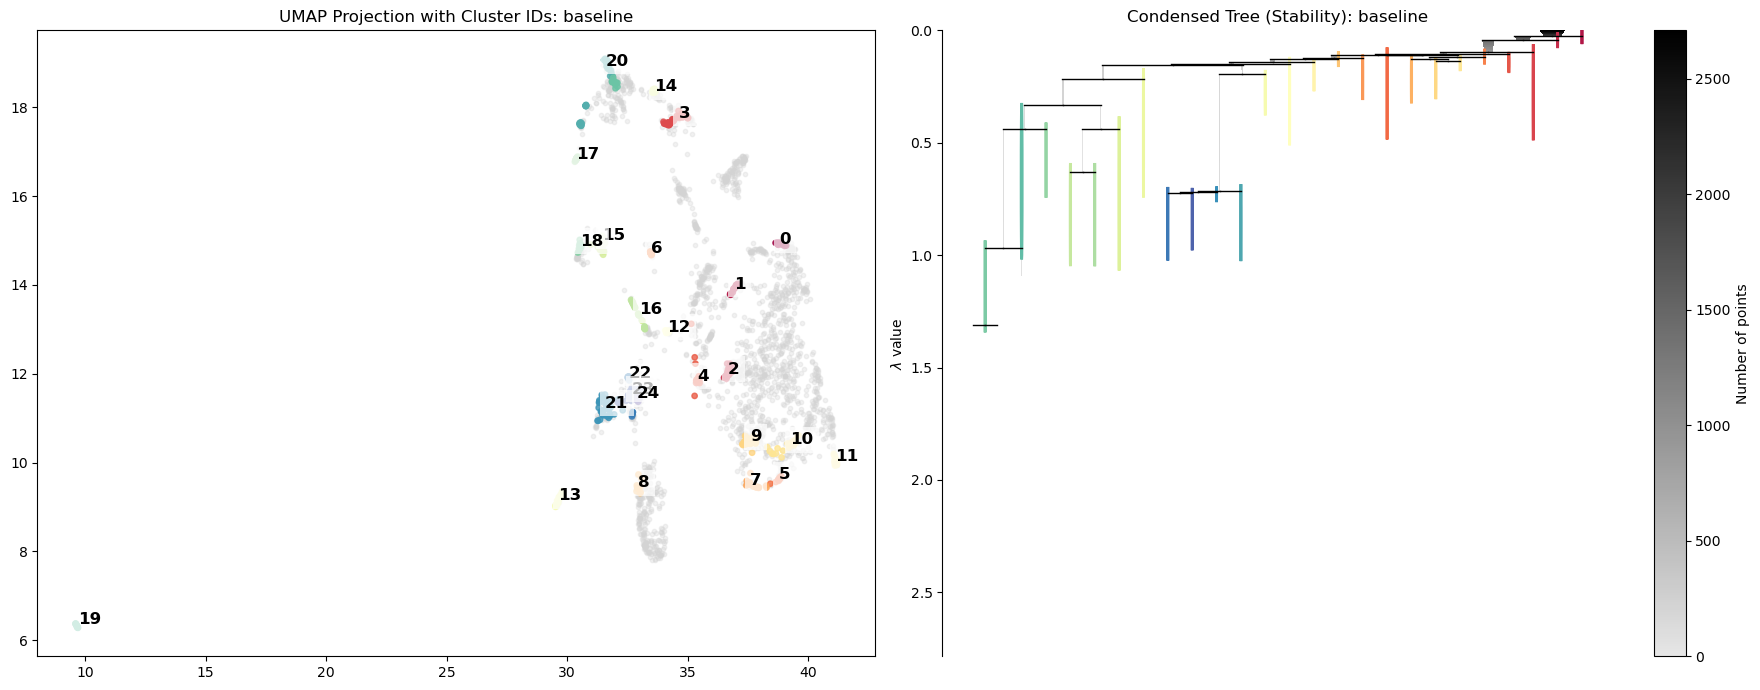


--- Processing: svd ---


/opt/miniconda3/envs/duohack/lib/python3.11/site-packages/hdbscan/prediction.py:663: RuntimeWarning: invalid value encountered in scalar divide
  in_cluster_probs = all_points_prob_in_some_cluster(


Original Noise: 212 (7.83%)
Soft Clustering has re-assigned all points to 2 clusters.
Saved results for svd to '../data/tmp/hdbscan/' folder.


/opt/miniconda3/envs/duohack/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


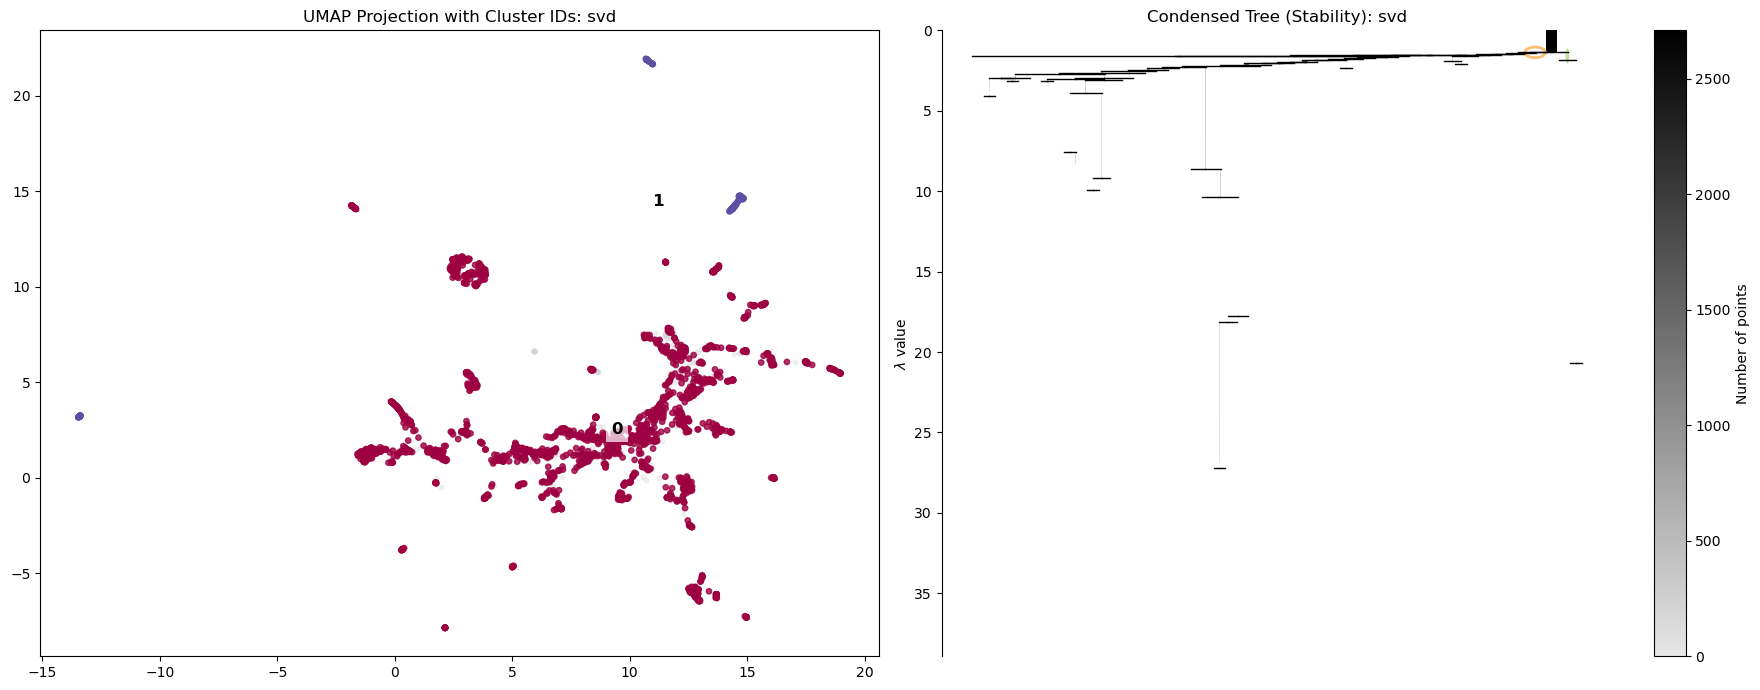


--- Processing: svd_B ---


/opt/miniconda3/envs/duohack/lib/python3.11/site-packages/hdbscan/prediction.py:663: RuntimeWarning: invalid value encountered in scalar divide
  in_cluster_probs = all_points_prob_in_some_cluster(


Original Noise: 98 (3.62%)
Soft Clustering has re-assigned all points to 1 clusters.
Saved results for svd_B to '../data/tmp/hdbscan/' folder.


/opt/miniconda3/envs/duohack/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


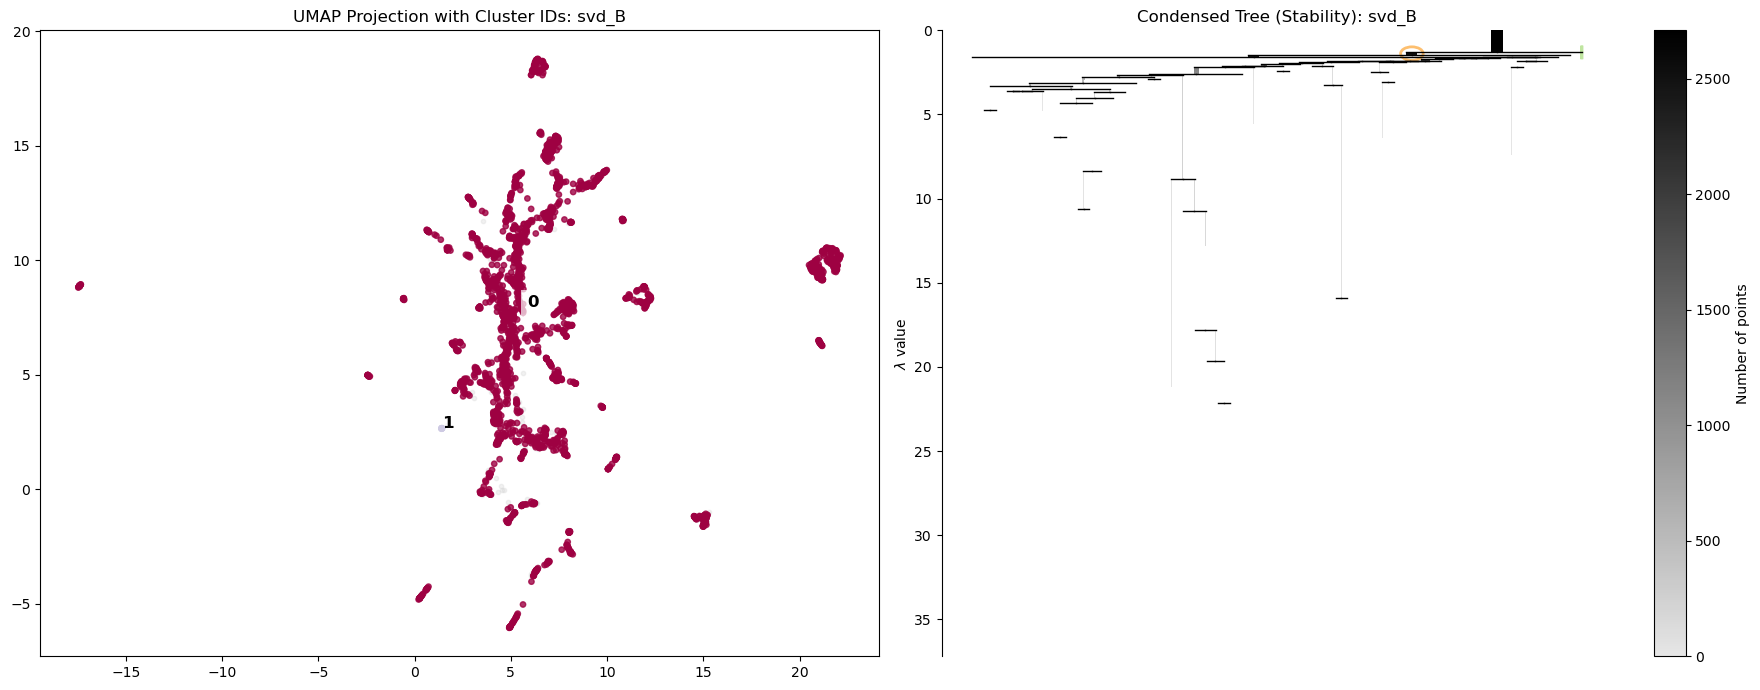


--- Processing: svd512_ae128 ---


/var/folders/rw/x_vg479j72xgn55l7gcx378r0000gn/T/ipykernel_26048/3202440721.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  processed_df, model = run_hdbscan_pipeline(df.reset_index(), n_components=min(df.shape[1],200),
/opt/miniconda3/envs/duohack/lib/python3.11/site-packages/hdbscan/prediction.py:663: RuntimeWarning: invalid value encountered in scalar divide
  in_cluster_probs = all_points_prob_in_some_cluster(


Original Noise: 778 (28.72%)
Soft Clustering has re-assigned all points to 2 clusters.
Saved results for svd512_ae128 to '../data/tmp/hdbscan/' folder.


/opt/miniconda3/envs/duohack/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


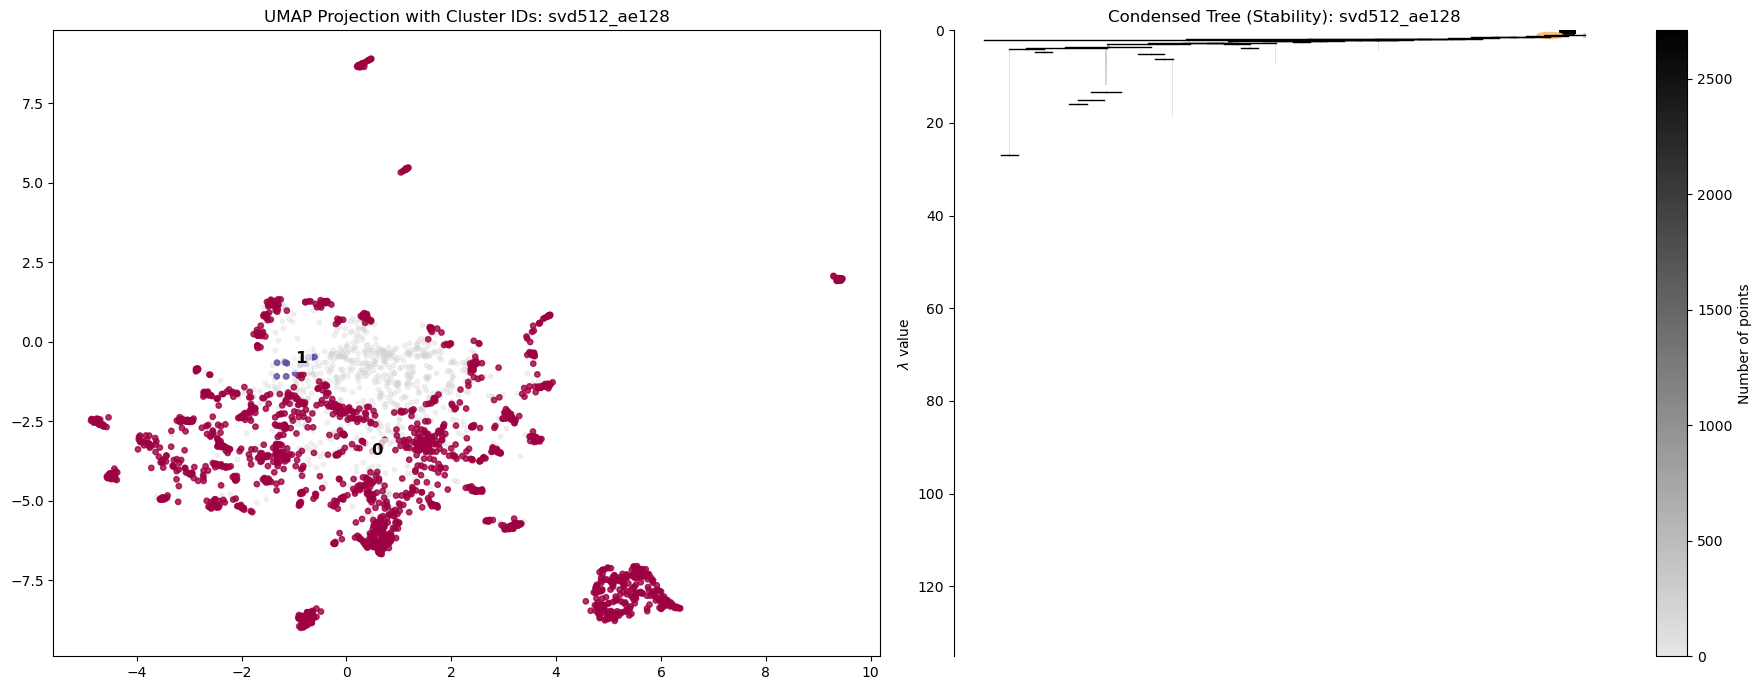


--- Processing: svd512_ae128_B ---


/var/folders/rw/x_vg479j72xgn55l7gcx378r0000gn/T/ipykernel_26048/3202440721.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  processed_df, model = run_hdbscan_pipeline(df.reset_index(), n_components=min(df.shape[1],200),
/opt/miniconda3/envs/duohack/lib/python3.11/site-packages/hdbscan/prediction.py:663: RuntimeWarning: invalid value encountered in scalar divide
  in_cluster_probs = all_points_prob_in_some_cluster(


Original Noise: 900 (33.22%)
Soft Clustering has re-assigned all points to 2 clusters.
Saved results for svd512_ae128_B to '../data/tmp/hdbscan/' folder.


/opt/miniconda3/envs/duohack/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


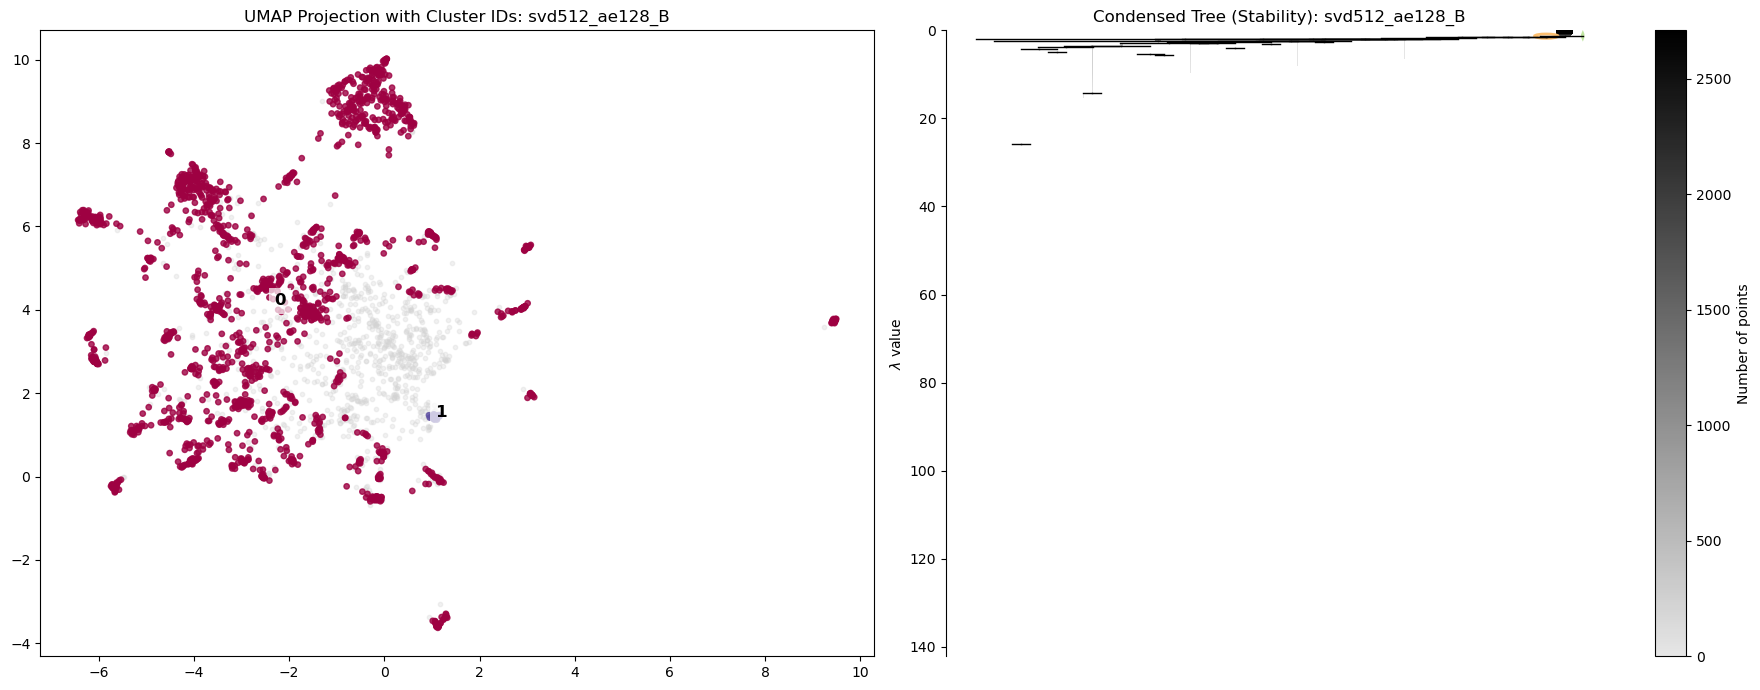


--- Processing: lex_clusters_B ---


/var/folders/rw/x_vg479j72xgn55l7gcx378r0000gn/T/ipykernel_26048/3202440721.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  processed_df, model = run_hdbscan_pipeline(df.reset_index(), n_components=min(df.shape[1],200),
/opt/miniconda3/envs/duohack/lib/python3.11/site-packages/hdbscan/prediction.py:663: RuntimeWarning: invalid value encountered in scalar divide
  in_cluster_probs = all_points_prob_in_some_cluster(


Original Noise: 1649 (60.87%)
Soft Clustering has re-assigned all points to 24 clusters.
Saved results for lex_clusters_B to '../data/tmp/hdbscan/' folder.


/opt/miniconda3/envs/duohack/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


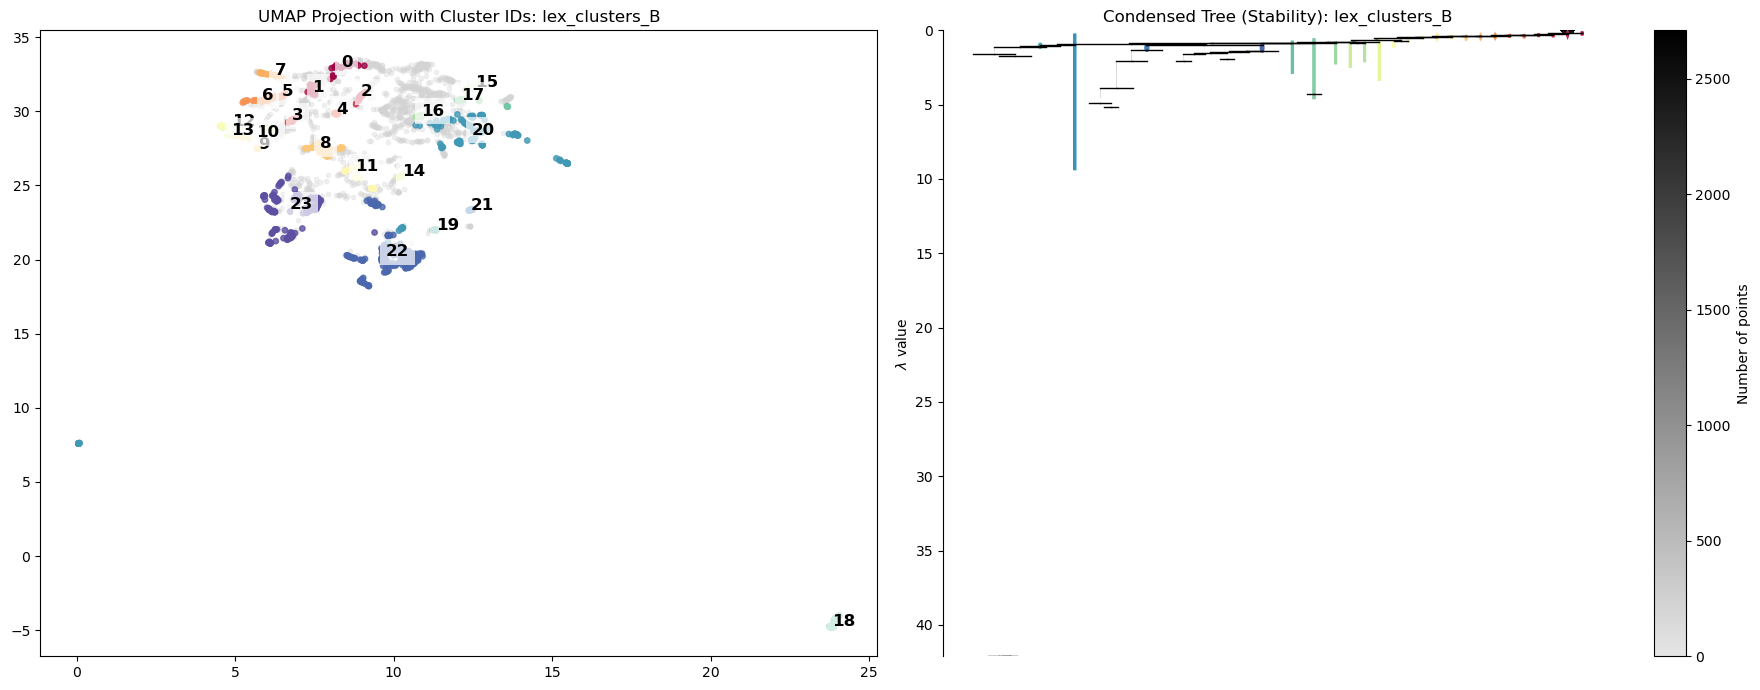

In [22]:
from src.models.HDBSCAN import run_hdbscan_pipeline, save_clustering_results, get_all_cluster_importances
from src.evaluation.visualize import visualize_hdbscan_with_labels, plot_cluster_top_features_boxplot, plot_cluster_top_features_radar

datasets = {
    "baseline": df_base, 
    "svd": df_1a, 
    "svd_B": df_1b,
    "svd512_ae128": df_2a, 
    "svd512_ae128_B": df_2b,
    "lex_clusters_B": df_3,
}

for name, df in datasets.items():
    print(f"\n--- Processing: {name} ---")
    
    # For the high-dim set, we ensure PCA/UMAP is used
    processed_df, model = run_hdbscan_pipeline(df.reset_index(), n_components=min(df.shape[1],200),
                                               epsilon=1.0, min_cluster_size=10, min_samples=2)
    
    save_clustering_results(processed_df, model, name, "../data/tmp/hdbscan")

    feature_cols = [c for c in processed_df.columns if c not in ['user_id', 'cluster_label', 'cluster_probability', 'soft_cluster_label', 'soft_cluster_score']]
    importance_dict = get_all_cluster_importances(processed_df, feature_cols)

    visualize_hdbscan_with_labels(processed_df, model, name, "../data/tmp/hdbscan/plots")

#### See Top Features per cluster compared to global average

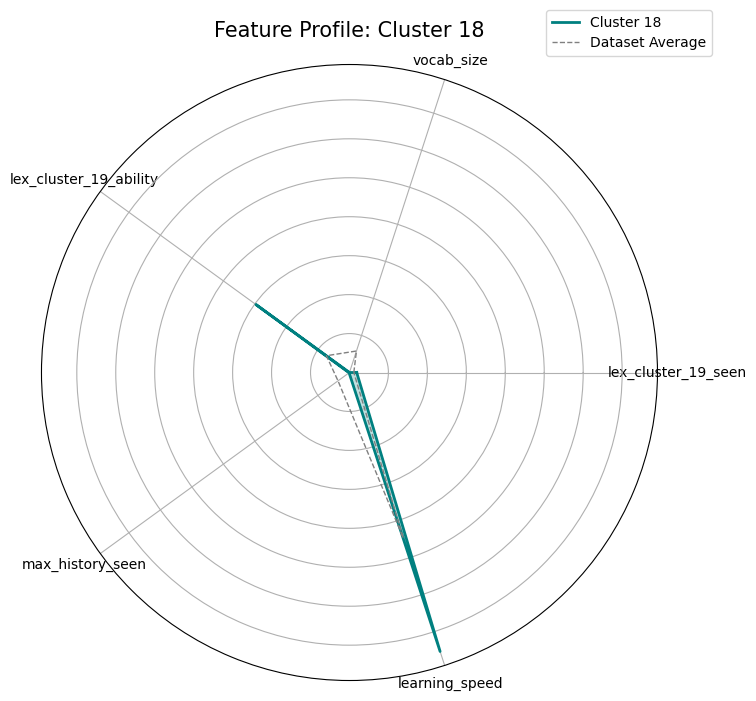

In [23]:
from src.evaluation.visualize import plot_cluster_top_features_radar

# Cluster 18 using df_3
plot_cluster_top_features_radar(processed_df, 18, importance_dict)

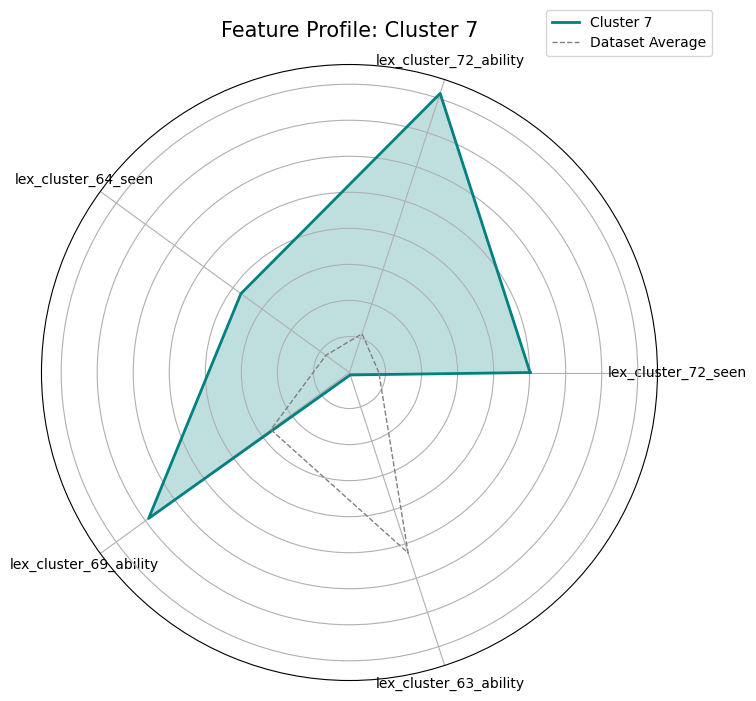

In [24]:
# Cluster 7 using df_3
plot_cluster_top_features_radar(processed_df, 7, importance_dict)